# Randomized Matrix multiplication
In this exercise we explore Algorithm 2 numerically. 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer

np.random.seed(123)

1. Assuming that the entries of $A \in \mathbb R^{m \times n}$ are double precision,  how large $m$ and $n$ can be to fit into 3 Gigabytes of memory? 

In [13]:
n = 4*10**5
m = 10**3

print('Memory consumption: ', m*n*8 / 1024**3, 'GB')

Memory consumption:  2.9802322387695312 GB


2. Generate $A \in \mathbb R^{m \times n}$ with $A_{i,j}$ being independent standard Gaussian r.v. (see *numpy.random.randn*). How long does it take? Use *default$_{-}$timer* function from *timeit* library.

In [14]:
start = timer()
A = np.random.randn(m, n)
end = timer()
print('Runtime: ', end - start) 

Runtime:  21.649847339023836


3. Calculate the product $A A^T \in \mathbb R^{m \times m}$ directly? How long does it take?

In [15]:
start = timer()
AAT = A @ A.T
end = timer()
direct_time = end - start
print('Runtime: ', direct_time)

AAT_norm = np.linalg.norm(AAT)

Runtime:  9.739381555002183


4. Write a function *rand_mat_mult* that implements Algorithm 2 from the lecture. Test your implementation with $c = n/10$ and uniform probabilities $p_i = 1/n$.

In [16]:
def rand_mat_mult(A, B, p, c, replacement = True):
    n = A.shape[1]
    idx = np.random.choice(n, size=c, replace=replacement, p=p)
    # Optional: sort
    idx = np.sort(idx)
    p_idx = p[idx]
    prod = (A[:, idx] * (1.0/p_idx[None, :])) @ B[idx, :] / c
    
    return prod

In [17]:
c = int(0.1*n)
p_unif = np.ones(n)*1.0/n
start = timer()
rAAT = rand_mat_mult(A, A.T, p_unif, c)
end = timer()
print('Runtime: ', end - start) 

err = np.linalg.norm(AAT - rAAT) / AAT_norm
print('Relative error:', err)

Runtime:  3.5108811219688505
Relative error: 0.15829129132286396


5. Compute optimal probabilities $p$ derived in the lecture. Print out the minimum and maximal $p_i$. What do we observe?  

In [18]:
norms = np.linalg.norm(A, axis=0)**2
p_opt = norms / np.sum(norms)

print(f"Optimal p: [{np.min(p_opt)}, {np.max(p_opt)}]")
print(f"Uniform distribution p: {p_unif[0]}")
print("Uniform distribution is very close to optimal p")

Optimal p: [2.0156774531314657e-06, 3.0660153075821883e-06]
Uniform distribution p: 2.5e-06
Uniform distribution is very close to optimal p


6. Now, run Algorithm 2 with optimal probabilities for $c = \{ \frac{n}{2q}, \frac{2n}{2q}, \ldots, \frac{q n}{2q} \}$ for $q = 20$. Plot relative errors $\|S - AB\|_F / \|AB\|_F$ and store the runtimes. For which subsampling ratio $\frac{k}{2q}$ the error drops below $0.1$? Is the runtime smaller than for the direct multiplication?

In [19]:
def test_different_c(M, MMT, p, factor=50, replacement=True):
    n = M.shape[1]
    f_list = 1 + np.arange(factor)
    c_list = 1.0 * n/2 * f_list / factor
    c_list = c_list.astype(int)

    errs = np.zeros((factor))
    times = np.zeros((factor))

    MMT_norm = np.linalg.norm(MMT)
    for ci in range(factor):
        c = c_list[ci]
        start = timer()
        rMMT = rand_mat_mult(M, M.T, p_opt, c, replacement)
        end = timer()
        times[ci] = end - start
        errs[ci] = np.linalg.norm(rMMT - MMT) / MMT_norm

        print(ci+1, 'out of', factor, 'c =', c, ' Rel.err.: ', errs[ci], ' Time: ', times[ci])
        
    return 0.5*f_list / factor, errs, times

def plot_results(fact, errs, times):
    plt.subplot(2,1,1)
    plt.plot(fact, errs)
    plt.ylabel("Relative error")
    # plt.xlabel(r"Reduction factor $\alpha$ in $c= \alpha n$")
    plt.subplot(2,1,2)
    plt.plot(fact, times)
    plt.plot(fact, np.repeat(direct_time, len(fact)), 'r--')
    plt.ylabel("Runtime")
    plt.xlabel(r"Reduction factor $\alpha$ in $c= \alpha n$")
    plt.show()

1 out of 20 c = 10000  Rel.err.:  0.3160028845779957  Time:  8.483738653943874
2 out of 20 c = 20000  Rel.err.:  0.2229547114846516  Time:  1.4556649349397048
3 out of 20 c = 30000  Rel.err.:  0.18227158257870624  Time:  2.0266821330878884
4 out of 20 c = 40000  Rel.err.:  0.1577191821027073  Time:  2.5468959290301427
5 out of 20 c = 50000  Rel.err.:  0.1412089120366457  Time:  3.121450087055564
6 out of 20 c = 60000  Rel.err.:  0.1288103238293466  Time:  4.009415231063031
7 out of 20 c = 70000  Rel.err.:  0.11922939721150438  Time:  5.53034556703642
8 out of 20 c = 80000  Rel.err.:  0.11133433041352095  Time:  6.130680172936991
9 out of 20 c = 90000  Rel.err.:  0.10551670345234396  Time:  6.177007613936439
10 out of 20 c = 100000  Rel.err.:  0.09972217024710496  Time:  6.208928061067127
11 out of 20 c = 110000  Rel.err.:  0.09503275357955743  Time:  9.138458144967444
12 out of 20 c = 120000  Rel.err.:  0.09109377953354095  Time:  13.460847998037934
13 out of 20 c = 130000  Rel.err.:  

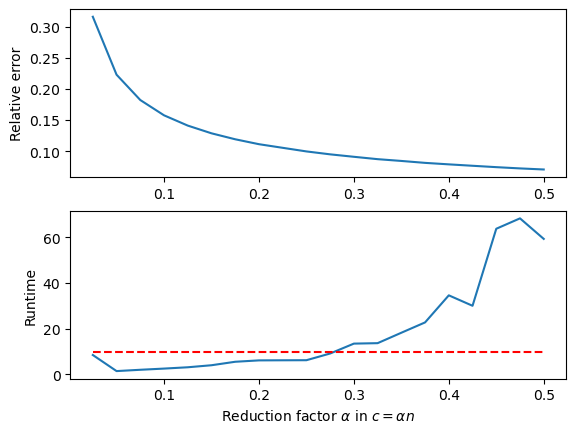

In [20]:
fact, errs, times = test_different_c(A, AAT, p_opt, 20)
plot_results(fact, errs, times)

# Computations become slower as we get higher accuracy
# Direct multiplication is in most cases much slower

7. Construct matrix $B \in \mathbb R^{m \times n}$ with columns
$$
		B^{(i)} = \begin{cases}
			10 A^{(i)}, & i \in [n/10], \\
			A^{(i)}, & \text{otherwise}.
		\end{cases}
$$
Repeat the previous point for $B$.

Runtime:  24.828682890045457
1.8490418675185968e-07 2.720281113700841e-05
1 out of 20 c = 10000  Rel.err.:  0.90585834926589  Time:  7.894965201034211
2 out of 20 c = 20000  Rel.err.:  0.6424368539315511  Time:  1.4228264479897916
3 out of 20 c = 30000  Rel.err.:  0.5266055997412463  Time:  2.027557624038309
4 out of 20 c = 40000  Rel.err.:  0.46141845522396985  Time:  2.5278144439216703
5 out of 20 c = 50000  Rel.err.:  0.4089382040900321  Time:  3.080417126067914
6 out of 20 c = 60000  Rel.err.:  0.37069156788757707  Time:  3.6107991710305214
7 out of 20 c = 70000  Rel.err.:  0.35217359115272695  Time:  4.180326023953967
8 out of 20 c = 80000  Rel.err.:  0.31734892784530455  Time:  4.826239217072725
9 out of 20 c = 90000  Rel.err.:  0.3005415176557383  Time:  5.1887714070035145
10 out of 20 c = 100000  Rel.err.:  0.288616806245913  Time:  5.77158886496909
11 out of 20 c = 110000  Rel.err.:  0.2725127281879972  Time:  7.954508552909829
12 out of 20 c = 120000  Rel.err.:  0.26287268582

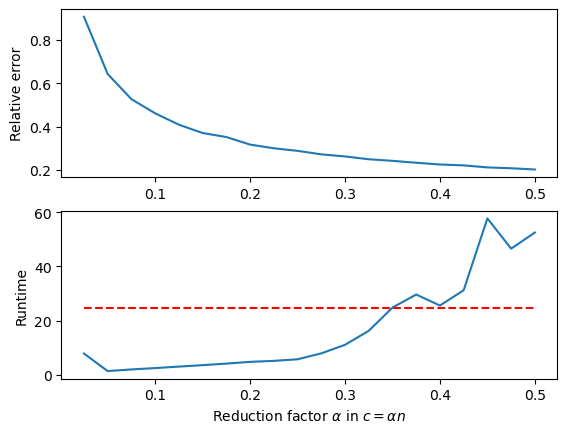

In [21]:
sc = np.ones(n)
sc[:n//10] = 10
B = A * sc[None, :]
start = timer()
BBT = B @ B.T
end = timer()
direct_time = end - start
print('Runtime: ', direct_time)

norms_B =  np.linalg.norm(B, axis=0)**2
p_opt_B = norms_B / np.sum(norms_B)
print(np.min(p_opt_B), np.max(p_opt_B))

fact_B, errs_B, times_B = test_different_c(B, BBT, p_opt_B, 20)
plot_results(fact_B, errs_B, times_B)

8. Set $C \in \mathbb R^{m \times n}$ as $10$-best rank approximation of $A$ and repeat point 6 again. Discuss what it the source of differences in performance between $A$,$B$ and $C$.

Runtime:  20.374664760078304
9.263735316867615e-08 1.0966597350093197e-05
1 out of 20 c = 10000  Rel.err.:  0.026969304227249524  Time:  8.38966951391194
2 out of 20 c = 20000  Rel.err.:  0.021321417391108623  Time:  1.4901126089971513
3 out of 20 c = 30000  Rel.err.:  0.017482614470281335  Time:  2.0814554590033367
4 out of 20 c = 40000  Rel.err.:  0.014460642062689901  Time:  2.622879150090739
5 out of 20 c = 50000  Rel.err.:  0.013697241105353229  Time:  3.1206090489868075
6 out of 20 c = 60000  Rel.err.:  0.01244797624288029  Time:  3.6409436330432072
7 out of 20 c = 70000  Rel.err.:  0.010879281983408656  Time:  4.177680189954117
8 out of 20 c = 80000  Rel.err.:  0.01025817784996254  Time:  5.397666246048175
9 out of 20 c = 90000  Rel.err.:  0.010254937708657872  Time:  5.263242527958937
10 out of 20 c = 100000  Rel.err.:  0.010080220805660772  Time:  5.778354995069094
11 out of 20 c = 110000  Rel.err.:  0.009088090262630919  Time:  9.633809720049612
12 out of 20 c = 120000  Rel.e

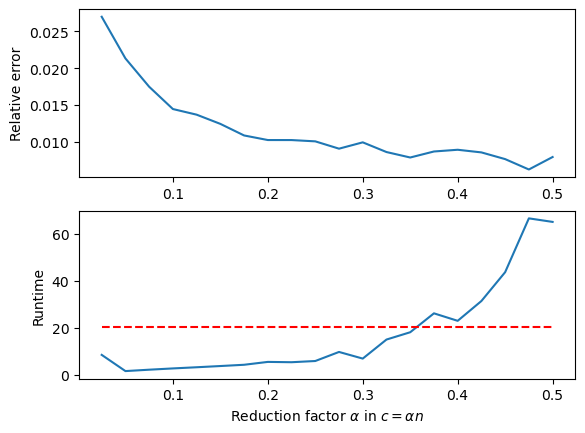

In [22]:
from scipy.sparse.linalg import svds

U, sv, VT = svds(A, k=10)
C = U @ np.diag(sv) @ VT

start = timer()
CCT = C @ C.T
end = timer()
direct_time = end - start
print('Runtime: ', direct_time)

norms_C = np.linalg.norm(C, axis=0)**2
p_opt_C = norms_C / np.sum(norms_C)
print(np.min(p_opt_C), np.max(p_opt_C))

fact_C, errs_C, times_C = test_different_c(C, CCT, p_opt_C, 20)
plot_results(fact_C, errs_C, times_C)